# Latent geometry across contractive input geometry, penalty metric and weight

This notebook measures what the contractive penalty does to the encoder's latent
representation, independently of any classification head. It asks how the code cloud's
shape, its dimensional usage, its sensitivity to input perturbation and its reproducibility
across seeds change as the penalty's input geometry, metric and weight vary.

The penalty is applied to the encoder, so this is where its direct effect lives.
`part_1` measures the downstream prediction consequence and `part_3` relates the two.

## Introduction

The encoder ends in a `LayerNorm`, so its raw output $z$ carries a learned affine that is
free to absorb any scaling the penalty imposes. Undoing that affine yields the
canonicalized code $u$, which is what the penalty actually acts on and what every
statistic here is computed from. Without canonicalization a penalty could appear to shrink
the representation while the affine silently rescales it back, and the measurement would
report a change that the network has already undone.

### Assumptions

- **The penalized space and the measured space are not identical.** Training penalizes the
  Jacobian of $u$, as configured by `penalized_space: u`. Several statistics here, in
  particular the angular ones, describe the unit direction $q = \bar u/\lVert\bar u\rVert$
  obtained after centering. A change in $u$ need not translate proportionally into a
  change in $q$, so angular results characterize the representation as used downstream,
  not the quantity the optimizer minimized. Thresholds or weights calibrated on one of
  these maps do not transfer to the other.
- **Canonicalization assumes a `CNNEncoder`-shaped bottleneck.** `gamma` and `beta` are
  read from `model.encoder.bottleneck_layer[-1]`. Every campaign compared here uses the
  same `conv1d-ae-32-16-8-latent-10` architecture, so the assumption holds uniformly; it
  would not survive an architecture change.
- **Every statistic uses the complete evaluation split.** The two quadratic measures run
  on the accelerator, so no subsample is taken and no row selection has to be shared across
  models for comparability. The decoded pixel indices are still persisted, since the split
  is what defines the analysed population.
- **Repetitions differ only in run seeds.** Cross-repetition agreement therefore measures
  reproducibility under initialization and data ordering, not under resampling of the
  data itself.

### Notation

Let $u \in \mathbb{R}^{N \times D}$ be the canonicalized codes of $N$ pixels in latent
dimension $D$, obtained from the raw code $z$ and the bottleneck affine as
$u = (z-\beta)/\gamma$. Write $\bar u$ for the sample mean, $\Sigma = \operatorname{Cov}(u)$
for the population covariance with eigenvalues $\mu_1 \ge \dots \ge \mu_D$, and
$\theta_{ij}$ for the angle between the centered directions of pixels $i$ and $j$. A grid
cell is $c = (\text{geometry}, \text{penalty metric}, \lambda)$ with repetitions
$r = 0,\dots,4$.

In [1]:
import hashlib
import json
import os
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader import read_entropy_campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import penalty_sweep as sweep
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import sweep_evaluation as evaluation
from msi_autoencoder_wrapper.analysis.autoencoder.latent import sphere_geometry as geometry
from msi_autoencoder_wrapper.utils.logger import get_custom_logger
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

logger = get_custom_logger("latent_geometry_sweep")

2026-09-07 01:15:25,527 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-07 01:15:25,531 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-07 01:15:26,384 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-07 01:15:26,386 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 23 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-07 01:15:26,388 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-07 01:15:26,389 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-07 01:15:26,429 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-09-07 01:15:26,583 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 21 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-09-07 01:15:26,585 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 25 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Configuration and encoded sample

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
MODEL_STORE = WORKSPACE / "models" / MODEL_CONTEXT

FISHER_CAMPAIGN = "fischer-rao-spectral-hinge-experiment-20260906-01"
EUCLIDEAN_CAMPAIGN = "contractive-20260905-01"
BASELINE_CAMPAIGN = "bce-baseline-20260905-01"
CAMPAIGNS = [FISHER_CAMPAIGN, EUCLIDEAN_CAMPAIGN, BASELINE_CAMPAIGN]

TARGET_FIELD = "molecule"
HEAD_NAME = "molecule_primary"
BATCH_SIZE = 256
PIXEL_FRACTION = 1.0
SAMPLE_SEED = 42
DECODE_CACHE = Path("data/kidney_workspace/cache/materialized_splits")
PAIR_COUNT = 5000
KNN_NEIGHBORS = 10
EPSILONS = (0.001, 0.003, 0.01, 0.03, 0.1)

ARTIFACT_DIR = Path("assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/part_2_latent_geometry_metric_weight_sweep_results")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

theme = resolve_theme(None)
theme.apply()

grid_rows = []
for campaign_id in CAMPAIGNS:
    status = WORKSPACE / "configs" / "entropy-runs" / campaign_id / "plan" / "status"
    tasks = read_entropy_campaign(status, MODEL_STORE, load_artifacts=False)
    grid_rows += [row for row in sweep.sweep_grid_frame(tasks, campaign_id) if row["status"] == "completed"]
grid_frame = pd.DataFrame(grid_rows)
print(f"{len(grid_frame)} completed run(s) across {grid_frame['cell_label'].nunique()} grid cell(s)")

2026-09-07 01:15:26,797 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:71 | Reading 75 entropy task manifest(s) from 'data/kidney_workspace/configs/entropy-runs/fischer-rao-spectral-hinge-experiment-20260906-01/plan/status'.


2026-09-07 01:15:27,881 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:97 | Entropy campaign at 'data/kidney_workspace/configs/entropy-runs/fischer-rao-spectral-hinge-experiment-20260906-01/plan/status': 75 task(s) read.


2026-09-07 01:15:27,882 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:230 | Campaign 'fischer-rao-spectral-hinge-experiment-20260906-01': 75 task(s), 75 completed, 15 distinct grid cell(s).


2026-09-07 01:15:27,884 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:71 | Reading 60 entropy task manifest(s) from 'data/kidney_workspace/configs/entropy-runs/contractive-20260905-01/plan/status'.


2026-09-07 01:15:28,656 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:97 | Entropy campaign at 'data/kidney_workspace/configs/entropy-runs/contractive-20260905-01/plan/status': 60 task(s) read.


2026-09-07 01:15:28,657 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:230 | Campaign 'contractive-20260905-01': 60 task(s), 60 completed, 12 distinct grid cell(s).


2026-09-07 01:15:28,658 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:71 | Reading 5 entropy task manifest(s) from 'data/kidney_workspace/configs/entropy-runs/bce-baseline-20260905-01/plan/status'.


2026-09-07 01:15:28,715 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:97 | Entropy campaign at 'data/kidney_workspace/configs/entropy-runs/bce-baseline-20260905-01/plan/status': 5 task(s) read.


2026-09-07 01:15:28,716 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:230 | Campaign 'bce-baseline-20260905-01': 5 task(s), 5 completed, 1 distinct grid cell(s).


140 completed run(s) across 28 grid cell(s)


In [3]:
for campaign_id in (FISHER_CAMPAIGN, EUCLIDEAN_CAMPAIGN):
    evaluation.link_campaign_scratch_workspace(f"/tmp/ms488923/msi-wrapper/{campaign_id}/workspace", WORKSPACE)

wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)
wrapper.load_configuration(model_name=grid_frame.iloc[0]["model_name"])
partitions = wrapper.active_dataset.create_partitions()

test_split = evaluation.materialize_split(partitions, "test", TARGET_FIELD, fraction=PIXEL_FRACTION, seed=SAMPLE_SEED, cache_directory=DECODE_CACHE)
print(f"test: {test_split.sampled}/{test_split.total} pixel(s) decoded ({test_split.sampled / test_split.total:.1%})")


def load_model(model_name: str):
    return wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)

2026-09-07 01:15:28,759 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-09-07 01:15:28,761 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-09-07 01:15:28,762 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-09-07 01:15:28,763 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-07 01:15:28,764 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-09-07 01:16:10,364 | INFO     | msi_autoencoder_wrapper.core.mixins.active_context.active_context_mixin:113 | Successfully bound active context memory maps for: kidney


2026-09-07 01:16:31,225 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:203 | Mapped annotation index: retained_rows=420649 retained_entries=10495756 coordinate_system=binner.


2026-09-07 01:16:31,439 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:275 | Selected 420649/421955 source spectra after annotation policies.


2026-09-07 01:16:33,654 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.sweep_evaluation:263 | Reusing cached split 'test' (4205 pixels) from data/kidney_workspace/cache/materialized_splits/test_f4d4be4539fed078.npz.


test: 4205/4205 pixel(s) decoded (100.0%)


## Encoding every model and its cloud statistics

### Methodology

#### Theoretical

Four statistics summarize the canonicalized cloud, each answering a different question
about what a penalty did:

- **Cloud asymmetry**, $\lVert\bar u\rVert^2/D$, measures how far the sample mean sits from
  the center. Under the population covariance convention the identity
  $\operatorname{tr}\Sigma = D - \lVert\bar u\rVert^2$ holds exactly, so a cloud that
  drifts off center spends part of a fixed budget on its mean rather than on variation.
- **Trace**, $\operatorname{tr}\Sigma$, is the total variation in the code. It is bounded
  above by $D$ and falls as the penalty contracts the representation. It is the most
  direct measure of collapse.
- **Effective rank**, $\exp(-\sum_d p_d \log p_d)$ with $p_d = \mu_d/\sum_j \mu_j$, is the
  exponential Shannon entropy of the normalized eigenvalue spectrum. It counts how many
  directions carry variation, irrespective of how much total variation there is.
- **Participation ratio**, $(\sum_d \mu_d)^2/\sum_d \mu_d^2$, answers the same question with
  a different weighting, being more sensitive to a few dominant directions.

Trace and effective rank must be read together: a representation can lose almost all its
variation while still spreading what remains over many directions, and the two statistics
separate exactly that case.

An intrinsic dimension estimate is also reported, but with a caveat established
empirically: the TwoNN estimator assumes locally uniform density, and under a strong
penalty the cloud collapses until nearest and second-nearest distances coincide, at which
point the estimator diverges. An estimate exceeding the ambient dimension $D$ is
impossible rather than merely implausible and is recorded as missing.

#### Implementation

Each completed run is loaded and encoded exactly once, canonicalized with the model's own
bottleneck affine, and reduced by `sphere_geometry`. Every statistic in this notebook,
including the angular structure, the sensitivity curve and the label-similarity agreement
below, is derived from that single encoding rather than from its own pass over the models.

Two of the measures, the intrinsic-dimension estimate and the neighborhood overlap, are
quadratic in the pixel count and were previously the reason to evaluate a subsample. They
now run through `latent.batch_geometry`, which computes them as tensor operations on the
accelerator and is asserted to agree with the `sphere_geometry` reference, so the complete
evaluation split is analysed and no row selection is needed.

#### Figure descriptions

A grid of panels, one per statistic named in the panel title. The x-axis lists grid cells
ordered by input geometry, then penalty metric, then weight; the y-axis is the statistic's
value on the evaluation split. Each violin is the distribution over the five repetitions
of that cell and each point is one repetition. Color encodes the penalty family. The
dashed horizontal line is the baseline's mean. For trace, effective rank and participation
ratio a fall means a more contracted or lower-dimensional representation; for cloud
asymmetry a rise means the cloud has drifted off center.

### Remarks

### Notes

In [4]:
# One pass over every model: load and encode once, then derive every statistic from that
# single encoding. Splitting these into a loop per statistic family, as this analysis was
# first written, loads and encodes each model four times over.
sensitivity_rng = np.random.default_rng(SAMPLE_SEED + 3)
rsa_rng = np.random.default_rng(SAMPLE_SEED + 4)
structure_rng = np.random.default_rng(SAMPLE_SEED + 1)
rsa_labels = test_split.targets * test_split.mask
sensitivity_inputs = test_split.spectra.numpy()

geometry_rows, structure_rows, sensitivity_rows, rsa_rows = [], [], [], []
cos_samples, latent_by_cell = {}, {}

for position, record in enumerate(grid_frame.to_dict("records"), start=1):
    model = load_model(record["model_name"])
    model.eval()
    gamma, beta = geometry.encoder_layer_norm_parameters(model)
    cell = sweep.PenaltySweepCell(
        penalty_metric=record["penalty_metric"], input_geometry=record["input_geometry"],
        weight=record["weight"], hinge_threshold=record["hinge_threshold"],
        hinge_alpha=record["hinge_alpha"], penalized_space=record["penalized_space"],
        calculation_method=record["calculation_method"],
    )

    ## Single encoding of the shared sample, reused by every statistic below
    latent = evaluation.canonical_latent(model, test_split.spectra, batch_size=BATCH_SIZE)

    ## Cloud shape and dimensional usage
    geometry_rows += evaluation.latent_geometry_frame(
        latent, cell, split_name="test", model_name=record["model_name"],
        campaign=record["campaign"], repetition=record["repetition"],
    )
    if record["repetition"] is not None:
        latent_by_cell.setdefault((cell.label, "test"), {})[int(record["repetition"])] = latent

    ## Angular structure, on the first repetition of each cell
    if record["repetition"] == 0:
        result = geometry.structure_test(latent, structure_rng, pair_count=PAIR_COUNT, return_samples=True)
        cos_samples[cell.label] = np.asarray(result["cos_theta_samples"])
        structure_rows.append({
            "cell_label": cell.label,
            **{key: value for key, value in result.items() if key != "cos_theta_samples"},
        })

    ## Encoder sensitivity to input perturbation
    def encode(batch: np.ndarray, _model=model, _gamma=gamma, _beta=beta) -> np.ndarray:
        with torch.no_grad():
            device = next(_model.parameters()).device
            codes = _model(torch.as_tensor(batch, dtype=torch.float32).to(device))["latent_space"]
        return geometry.canonicalize(codes.cpu().numpy(), _gamma, _beta)

    curve = geometry.angular_sensitivity_curve(encode, sensitivity_inputs, EPSILONS, sensitivity_rng)
    for epsilon, angle in zip(curve["epsilon"], curve["mean_angle_degrees"]):
        sensitivity_rows.append({
            "cell_label": cell.label, "campaign": record["campaign"],
            "penalty_metric": record["penalty_metric"], "input_geometry": record["input_geometry"],
            "weight": record["weight"], "repetition": record["repetition"],
            "epsilon": float(epsilon), "mean_angle_degrees": float(angle),
        })

    ## Agreement between latent similarity and label similarity
    rsa_rows.append({
        "cell_label": cell.label, "campaign": record["campaign"],
        "penalty_metric": record["penalty_metric"], "input_geometry": record["input_geometry"],
        "weight": record["weight"], "repetition": record["repetition"],
        **geometry.rsa_spearman(latent, rsa_labels, rsa_rng, pair_count=PAIR_COUNT),
    })

    if position % 20 == 0 or position == len(grid_frame):
        logger.info("Encoded and summarized %s/%s model(s).", position, len(grid_frame))

geometry_frame = pd.DataFrame(geometry_rows)
structure_frame = pd.DataFrame(structure_rows)
sensitivity_frame = pd.DataFrame(sensitivity_rows)
rsa_frame = pd.DataFrame(rsa_rows)
rsa_column = "spearman_r"
print(f"{len(geometry_frame)} geometry row(s) from {len(grid_frame)} encoded model(s)")

2026-09-07 01:16:33,780 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-07 01:16:33,780 | INFO     | msi_autoencoder_wrapper.models.model_loader:68 | Reconstructing loaded model family 'autoencoder'.


2026-09-07 01:16:33,781 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:173 | Initializing multi-component sub-graph resolution phase for model family: autoencoder


2026-09-07 01:16:33,782 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='encoder' using Strategy='CNNEncoder'.


2026-09-07 01:16:33,785 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='decoder' using Strategy='CNNDecoder'.


...

2026-09-07 01:19:43,495 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-09-07 01:19:43,498 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-07 01:19:43,503 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


2026-09-07 01:19:44,757 | INFO     | latent_geometry_sweep:69 | Encoded and summarized 140/140 model(s).


700 geometry row(s) from 140 encoded model(s)


19 run(s) had an inadmissible TwoNN estimate and are recorded as missing


cell_label
euclidean / spectral / w=1e-02                         5
euclidean / spectral / w=1e-03                         5
fisher_rao / spectral / w=1e-01                        4
fisher_rao / spectral_plus_hinged / w=1e-01 / tau=7    5
Name: runs, dtype: int64

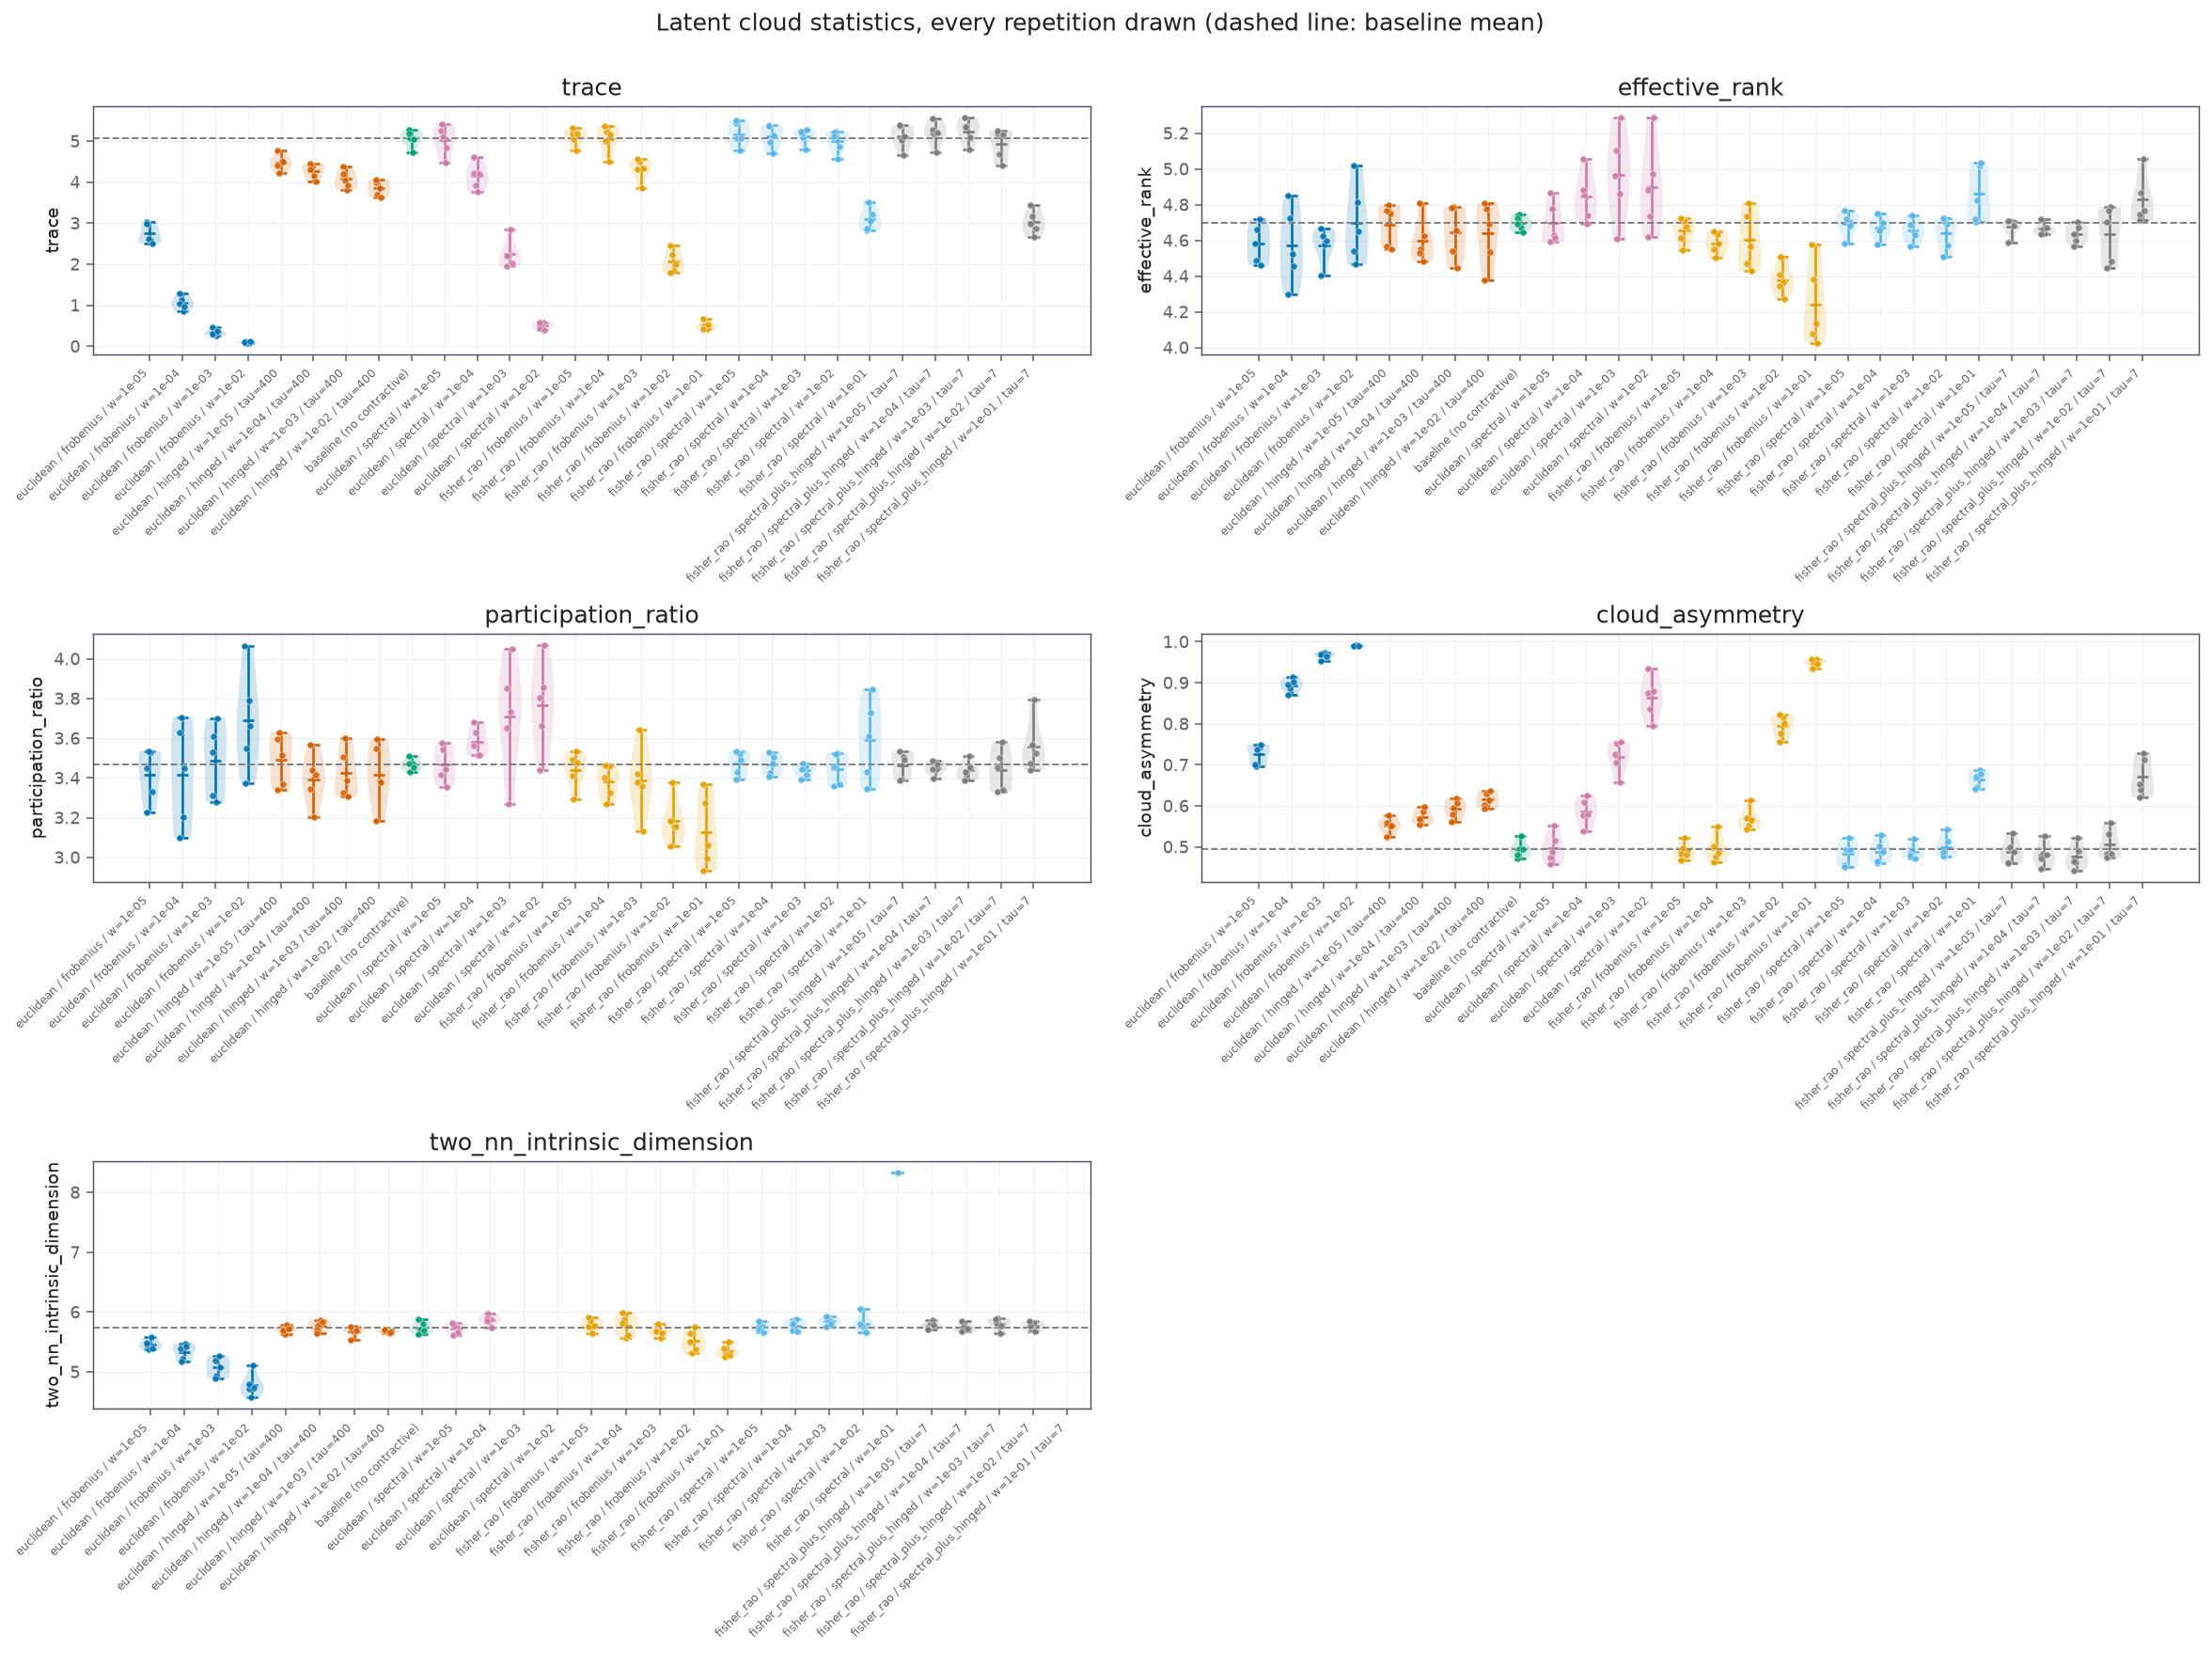

In [5]:
GEOMETRY_METRICS = ["trace", "effective_rank", "participation_ratio", "cloud_asymmetry", "two_nn_intrinsic_dimension"]
CELL_ORDER = (
    grid_frame.drop_duplicates("cell_label")
    .sort_values(["input_geometry", "penalty_metric", "weight"], na_position="first")
    ["cell_label"].tolist()
)
FAMILY_OF = grid_frame.drop_duplicates("cell_label").set_index("cell_label")[["input_geometry", "penalty_metric"]]
FAMILIES = sorted({tuple(FAMILY_OF.loc[cell]) for cell in CELL_ORDER})
FAMILY_COLOR = {family: theme.color_for_model("/".join(family), index) for index, family in enumerate(FAMILIES)}
CELL_COLOR = {cell: FAMILY_COLOR[tuple(FAMILY_OF.loc[cell])] for cell in CELL_ORDER}
BASELINE_CELL = "baseline (no contractive)"

figure, axes = plt.subplots(3, 2, figsize=(17.0, 12.5), dpi=theme.figure_dpi)
for axis, metric in zip(axes.ravel(), GEOMETRY_METRICS):
    selected = geometry_frame.query("metric == @metric").dropna(subset=["value"])
    samples = {cell: group["value"].to_numpy() for cell, group in selected.groupby("cell_label")}
    for position, cell in enumerate(CELL_ORDER):
        values = samples.get(cell)
        if values is None or not len(values):
            continue
        plot_violin_with_points(
            values, position=position, ax=axis, width=0.7,
            color=CELL_COLOR[cell], point_size=14.0, jitter=0.10, theme=theme,
        )
    if BASELINE_CELL in samples:
        axis.axhline(float(np.mean(samples[BASELINE_CELL])), color="grey", linestyle="--", linewidth=1)
    axis.set_xticks(range(len(CELL_ORDER)))
    axis.set_xticklabels(CELL_ORDER, rotation=45, ha="right", fontsize=6)
    axis.set(ylabel=metric, title=metric)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
axes.ravel()[-1].axis("off")
figure.suptitle("Latent cloud statistics, every repetition drawn (dashed line: baseline mean)", y=1.001, fontsize=13)
figure.tight_layout()

missing_two_nn = geometry_frame.query("metric == 'two_nn_intrinsic_dimension' and value.isna()", engine="python")
print(f"{len(missing_two_nn)} run(s) had an inadmissible TwoNN estimate and are recorded as missing")
if len(missing_two_nn):
    display(missing_two_nn.groupby("cell_label").size().rename("runs"))

## Angular structure of the code cloud

### Methodology

#### Theoretical

If the representation carried no structure, the directions of two randomly chosen pixels
would be distributed as two independent uniform directions on the sphere, whose expected
cosine is zero and whose spread narrows as $D$ grows. The observed distribution of
$\cos\theta_{ij}$ over random pixel pairs therefore has a well-defined null, and its
departure from that null quantifies how concentrated the representation is.

The relevant failure mode is concentration, not dispersion: a penalty that contracts the
code drives all directions toward one another, pushing the mean cosine toward one. A
representation whose random pairs are nearly parallel has lost the ability to distinguish
pixels regardless of what any downstream metric reports.

#### Implementation

`structure_test` draws `PAIR_COUNT` random pixel pairs with a seeded generator, computes
the cosine between their centered directions, and compares the result against the uniform
sphere null it derives for the same $D$. Repetition 0 of every cell is used, since the
statistic is over pixel pairs rather than over runs and five repetitions would not change
its shape.

#### Figure descriptions

One violin per grid cell showing the distribution of $\cos\theta$ over the sampled random
pixel pairs; points are a fixed subsample of 400 pairs per cell drawn with a seeded
generator, since drawing five thousand points per violin is unreadable, while the violin
itself uses every sampled pair. The x-axis lists cells in the standard order, the y-axis
is the cosine. The dotted line at zero is the uniform-sphere expectation. A distribution
centered near zero indicates directions spread over the sphere; one pushed toward one
indicates the codes have collapsed onto a common direction.

### Remarks

### Notes

In [6]:
COS_POINT_SAMPLE = 400
display(structure_frame.round(4))

,cell_label,observed_mean_cos_theta,observed_sd_cos_theta,uniform_baseline_sd_cos_theta,effective_dimension
0,fisher_rao / spectral / w=1e-05,0.5285,0.3350,0.3333,8.0
1,fisher_rao / spectral / w=1e-04,0.5240,0.3343,0.3333,8.0
2,fisher_rao / spectral / w=1e-03,0.5065,0.3387,0.3333,8.0
3,fisher_rao / spectral / w=1e-02,0.5490,0.3342,0.3333,8.0
4,fisher_rao / spectral / w=1e-01,0.6837,0.2290,0.3333,8.0
5,fisher_rao / spectral_plus_hinged / w=1e-05 / ...,0.5352,0.3335,0.3333,8.0
6,fisher_rao / spectral_plus_hinged / w=1e-04 / ...,0.5296,0.3364,0.3333,8.0
7,fisher_rao / spectral_plus_hinged / w=1e-03 / ...,0.5225,0.3302,0.3333,8.0
8,fisher_rao / spectral_plus_hinged / w=1e-02 / ...,0.5615,0.3199,0.3333,8.0
9,fisher_rao / spectral_plus_hinged / w=1e-01 / ...,0.7290,0.1941,0.3333,8.0


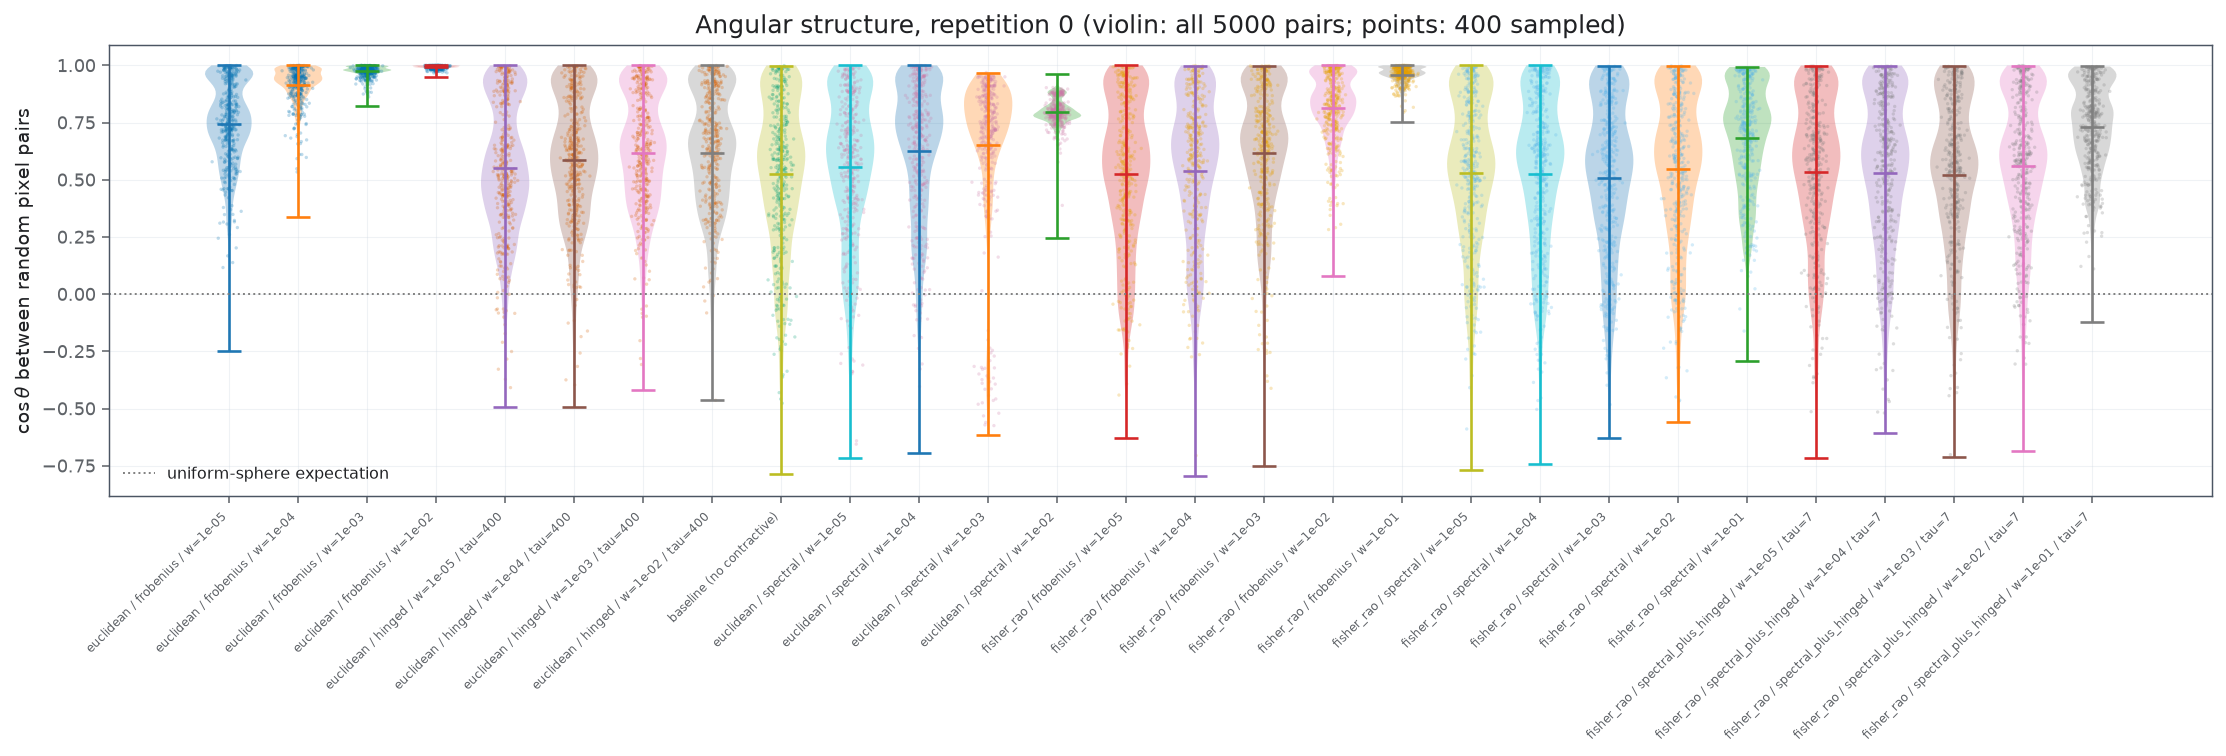

In [7]:
point_rng = np.random.default_rng(SAMPLE_SEED + 2)
figure, ax = plt.subplots(figsize=(16.0, 5.5), dpi=theme.figure_dpi)
for position, cell in enumerate(CELL_ORDER):
    values = cos_samples.get(cell)
    if values is None or not len(values):
        continue
    shown = values if len(values) <= COS_POINT_SAMPLE else point_rng.choice(values, COS_POINT_SAMPLE, replace=False)
    ax.violinplot([values], positions=[position], widths=0.7, showmeans=True)
    ax.scatter(
        position + point_rng.normal(0.0, 0.07, size=len(shown)), shown,
        color=CELL_COLOR[cell], s=3, alpha=0.25, edgecolor="none",
    )
ax.axhline(0.0, color="grey", linestyle=":", linewidth=1, label="uniform-sphere expectation")
ax.set_xticks(range(len(CELL_ORDER)))
ax.set_xticklabels(CELL_ORDER, rotation=45, ha="right", fontsize=6)
ax.set(ylabel=r"$\cos\theta$ between random pixel pairs", title=f"Angular structure, repetition 0 (violin: all {PAIR_COUNT} pairs; points: {COS_POINT_SAMPLE} sampled)")
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
ax.legend(fontsize=8, frameon=theme.legend_frame)
figure.tight_layout()

## Reproducibility of the representation across seeds

### Methodology

#### Theoretical

Every statistic so far describes one run. A penalty could improve the average shape of the
representation while leaving which representation is found entirely up to the seed, and
that distinction matters: a regularizer that makes the solution reproducible is doing
something a single-run shape statistic cannot show. All three measures used here are
invariant to the rotations the latent is only defined up to, so they compare
representations rather than coordinate systems:

- **Procrustes distance** is the residual after optimally rotating one cloud onto the
  other, so it measures disagreement that no rotation can remove. Lower is more
  reproducible.
- **Linear centered kernel alignment** compares the two clouds' similarity structures
  rather than their coordinates, giving one for identical structure and zero for unrelated
  ones.
- **Neighborhood overlap** is the fraction of each pixel's $k$ nearest neighbors that the
  two representations agree on, which is what matters if the representation is to be used
  for local structure rather than for global position.

#### Implementation

For each cell, every unordered pair of its five repetitions is compared, giving ten pairs
per cell. The comparison requires row alignment, which holds because every repetition
encodes the identical materialized pixel sample in the identical order. All three measures
come from `sphere_geometry`.

#### Figure descriptions

Three panels, one per measure named in the panel title. The x-axis lists grid cells in the
standard order, the y-axis is the measure. Each violin is the distribution over the ten
repetition pairs of that cell and each point is one pair. Color encodes the penalty family
and the dashed line is the baseline's mean. For Procrustes distance lower means more
reproducible; for centered kernel alignment and neighborhood overlap higher does.

### Remarks

### Notes

In [8]:
# One representative grid row per cell label, resolved once. `PenaltySweepCell`
# normalizes absent numeric fields, so a cell rebuilt from a frame row carries the
# same label as the one the evaluation keyed its results by.
cell_by_label, campaign_by_label = {}, {}
for record in grid_frame.to_dict("records"):
    label = record["cell_label"]
    if label in cell_by_label:
        continue
    cell_by_label[label] = sweep.PenaltySweepCell(
        penalty_metric=record["penalty_metric"], input_geometry=record["input_geometry"],
        weight=record["weight"], hinge_threshold=record["hinge_threshold"],
        hinge_alpha=record["hinge_alpha"], penalized_space=record["penalized_space"],
        calculation_method=record["calculation_method"],
    )
    campaign_by_label[label] = record["campaign"]

unresolved = sorted({label for label, _ in latent_by_cell} - set(cell_by_label))
if unresolved:
    raise KeyError(f"Encoded cells absent from the grid frame: {unresolved}")

stability_rows = []
for (cell_label, split_name), latents in latent_by_cell.items():
    if len(latents) < 2:
        continue
    stability_rows += evaluation.representation_stability_frame(
        latents, cell_by_label[cell_label], split_name=split_name,
        campaign=campaign_by_label[cell_label], knn_neighbors=KNN_NEIGHBORS,
    )
stability_frame = pd.DataFrame(stability_rows)
print(f"{len(stability_frame)} pairwise comparison(s) over {stability_frame['cell_label'].nunique()} cell(s)")

840 pairwise comparison(s) over 28 cell(s)


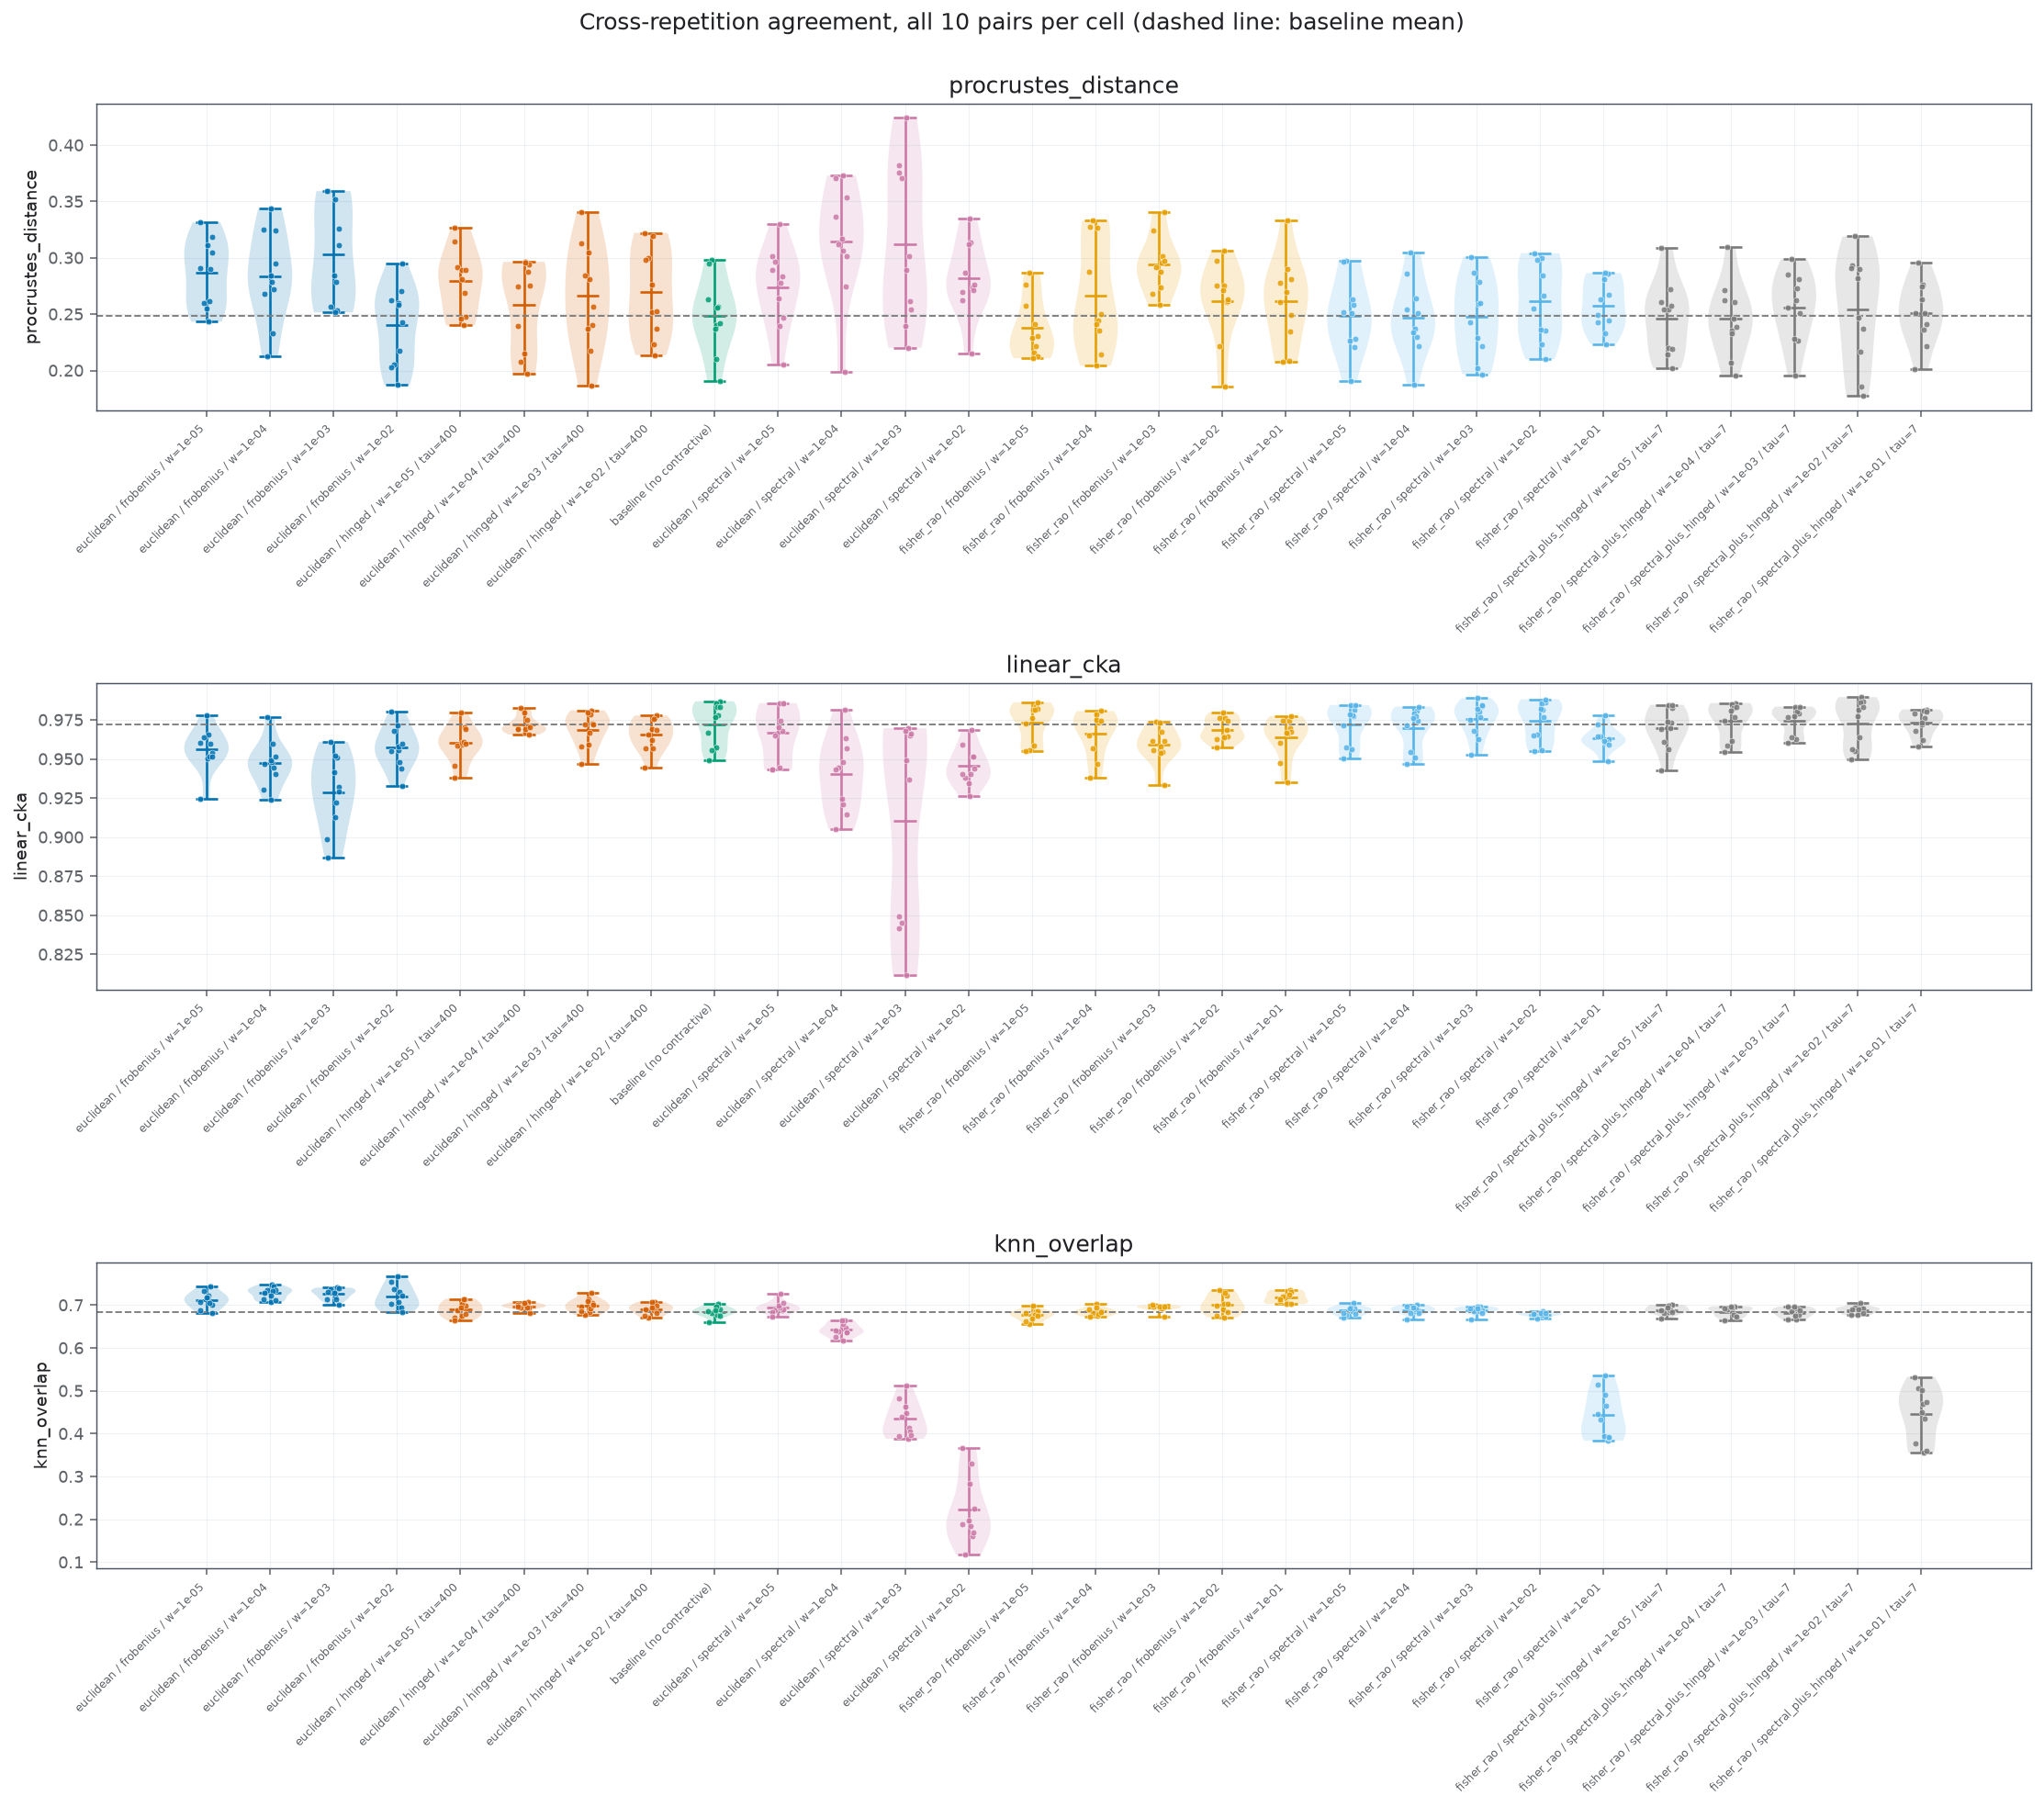

In [9]:
STABILITY_METRICS = ["procrustes_distance", "linear_cka", "knn_overlap"]
figure, axes = plt.subplots(3, 1, figsize=(16.0, 14.0), dpi=theme.figure_dpi)
for axis, metric in zip(axes, STABILITY_METRICS):
    selected = stability_frame.query("metric == @metric")
    samples = {cell: group["value"].to_numpy() for cell, group in selected.groupby("cell_label")}
    for position, cell in enumerate(CELL_ORDER):
        values = samples.get(cell)
        if values is None or not len(values):
            continue
        plot_violin_with_points(
            values, position=position, ax=axis, width=0.7,
            color=CELL_COLOR[cell], point_size=12.0, jitter=0.10, theme=theme,
        )
    if BASELINE_CELL in samples:
        axis.axhline(float(np.mean(samples[BASELINE_CELL])), color="grey", linestyle="--", linewidth=1)
    axis.set_xticks(range(len(CELL_ORDER)))
    axis.set_xticklabels(CELL_ORDER, rotation=45, ha="right", fontsize=6)
    axis.set(ylabel=metric, title=metric)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle(f"Cross-repetition agreement, all {int(len(stability_frame) / len(STABILITY_METRICS) / max(stability_frame['cell_label'].nunique(), 1))} pairs per cell (dashed line: baseline mean)", y=1.001, fontsize=13)
figure.tight_layout()

## Encoder sensitivity to input perturbation

### Methodology

#### Theoretical

The contractive penalty exists to reduce how far the code moves when the input moves. This
section measures that directly rather than through the penalty's own value, which is on a
geometry-specific scale and therefore not comparable across arms. For a relative
perturbation size $\varepsilon$, isotropic noise is added to the input and the angular
displacement of the canonicalized direction is recorded. The resulting curve
$\varepsilon \mapsto \mathbb{E}[\Delta\theta]$ is comparable across every cell because it
is defined on the input and the output, not on the penalty.

This is the quantity on which the two arms can legitimately be compared. Their nominal
weights cannot be compared, because $\lambda$ multiplies penalties measured in different
geometries; realized sensitivity is the common axis.

#### Implementation

`angular_sensitivity_curve` applies isotropic perturbations at each $\varepsilon$ with a
seeded generator and returns the mean angular displacement. It is evaluated for every
repetition of every cell, not only the first, so the curve carries its own spread. The
perturbation is isotropic in the ambient input space, which is deliberately not the
Fisher-Rao geometry one arm was trained under: using each arm's own geometry would make the
comparison circular.

#### Figure descriptions

The left panel plots relative perturbation size on a logarithmic x-axis against mean
angular displacement in degrees on the y-axis; each thin line is one repetition of one
cell and color encodes the penalty family, so a family's spread is visible rather than
averaged away. The right panel takes the largest perturbation and shows, per cell, the
distribution of displacement over the five repetitions as a violin with each repetition
drawn; lower means a less sensitive encoder, which is what the penalty is meant to produce.

### Remarks

### Notes

In [10]:
print(f"{len(sensitivity_frame)} sensitivity row(s) over {len(EPSILONS)} perturbation size(s)")

700 sensitivity row(s) over 5 perturbation size(s)


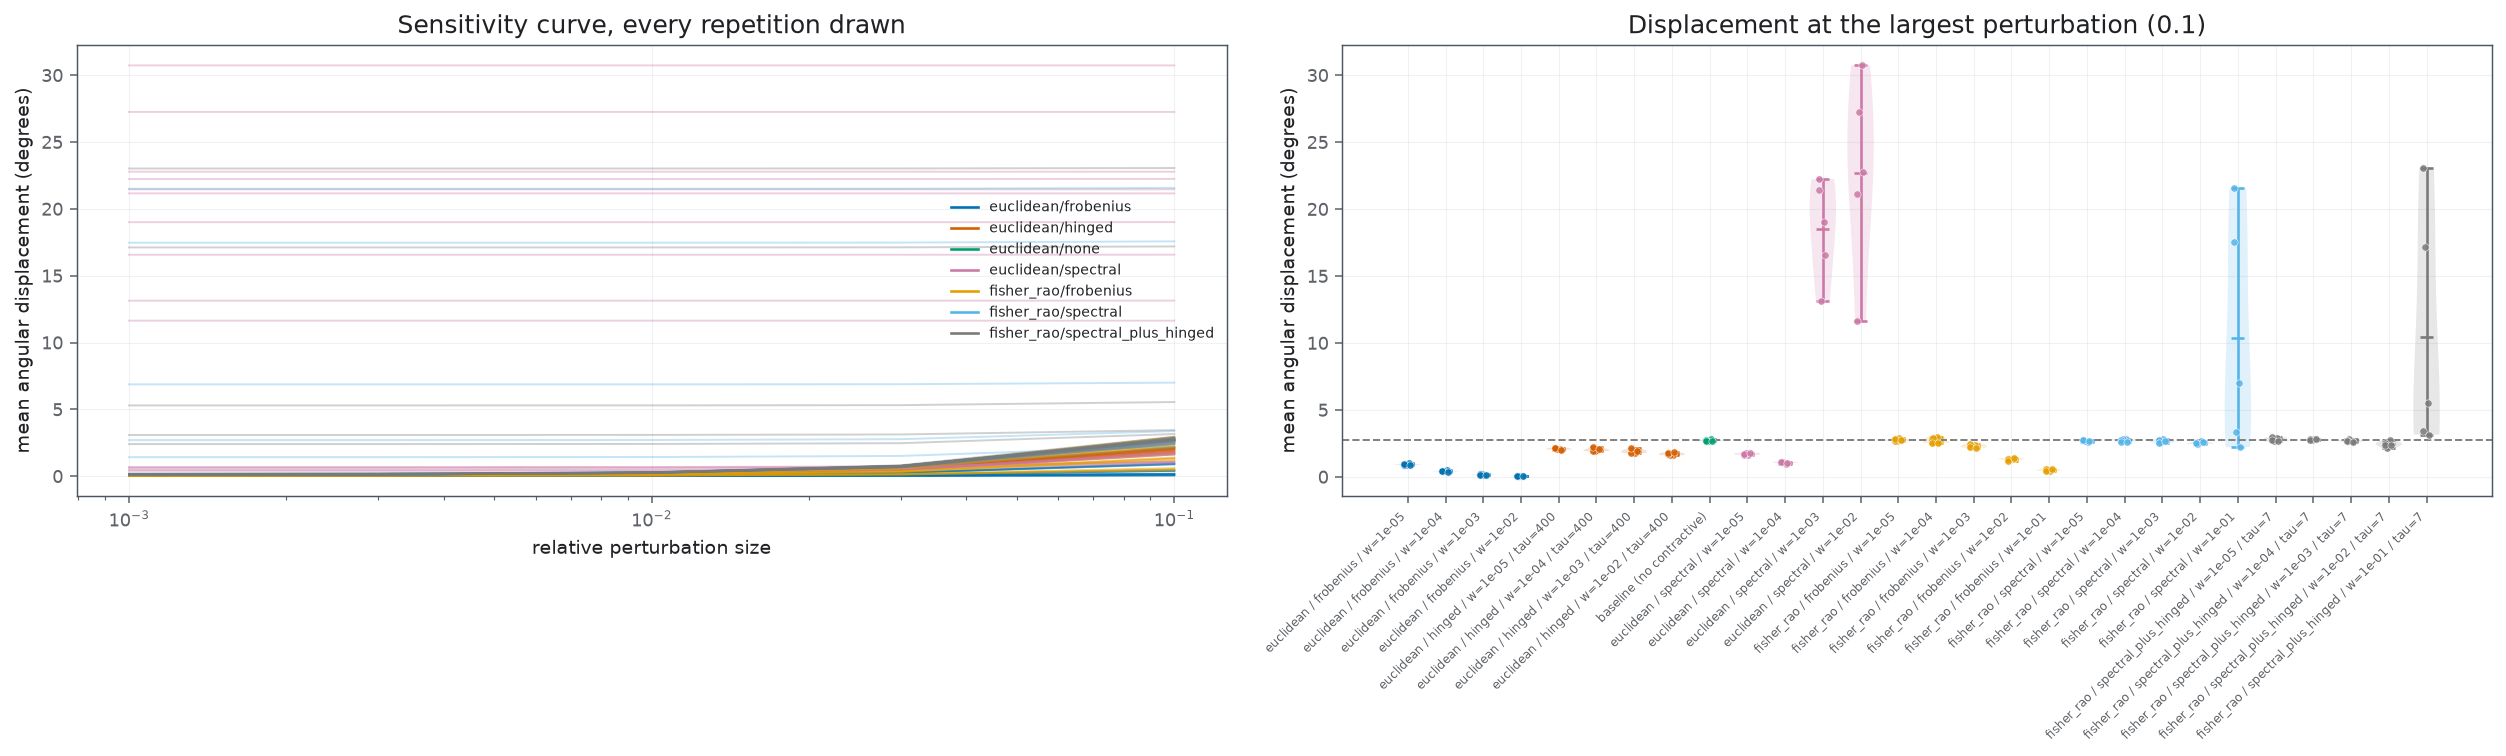

In [11]:
figure, (curve_axis, level_axis) = plt.subplots(1, 2, figsize=(18.0, 5.5), dpi=theme.figure_dpi)
for (cell, repetition), run in sensitivity_frame.groupby(["cell_label", "repetition"]):
    run = run.sort_values("epsilon")
    curve_axis.plot(run["epsilon"], run["mean_angle_degrees"], color=CELL_COLOR[cell], alpha=0.35, linewidth=1.0)
curve_axis.set_xscale("log")
curve_axis.set(xlabel="relative perturbation size", ylabel="mean angular displacement (degrees)", title="Sensitivity curve, every repetition drawn")
curve_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
handles = [plt.Line2D([], [], color=FAMILY_COLOR[f], label="/".join(f)) for f in FAMILIES]
curve_axis.legend(handles=handles, fontsize=7, frameon=theme.legend_frame)

largest = sensitivity_frame["epsilon"].max()
at_largest = sensitivity_frame.query("epsilon == @largest")
samples = {cell: group["mean_angle_degrees"].to_numpy() for cell, group in at_largest.groupby("cell_label")}
for position, cell in enumerate(CELL_ORDER):
    values = samples.get(cell)
    if values is None or not len(values):
        continue
    plot_violin_with_points(
        values, position=position, ax=level_axis, width=0.7,
        color=CELL_COLOR[cell], point_size=14.0, jitter=0.10, theme=theme,
    )
if BASELINE_CELL in samples:
    level_axis.axhline(float(np.mean(samples[BASELINE_CELL])), color="grey", linestyle="--", linewidth=1)
level_axis.set_xticks(range(len(CELL_ORDER)))
level_axis.set_xticklabels(CELL_ORDER, rotation=45, ha="right", fontsize=6)
level_axis.set(ylabel="mean angular displacement (degrees)", title=f"Displacement at the largest perturbation ({largest:g})")
level_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.tight_layout()

## Agreement between latent similarity and label similarity

### Methodology

#### Theoretical

The statistics above describe the representation's shape without reference to what it
should encode. Representational similarity analysis closes that gap: it asks whether pixels
whose codes are similar also carry similar molecule labels. Formally it is the Spearman
correlation, over random pixel pairs, between the latent similarity of a pair and its label
similarity. A representation can be well spread and highly reproducible while carrying no
label-relevant structure at all, and only this statistic distinguishes that case.

#### Implementation

`rsa_spearman` draws `PAIR_COUNT` random pixel pairs with a seeded generator and correlates
their latent cosine similarity against their label similarity, using the materialized
split's targets. It is computed for every repetition of every cell so the result carries a
distribution rather than a single value.

#### Figure descriptions

One violin per grid cell showing the distribution over the five repetitions of the
representational similarity correlation on the evaluation split; each point is one
repetition. The x-axis lists cells in the standard order and the y-axis is Spearman's
$\rho$. The dashed line is the baseline's mean and the dotted line at zero marks no
association between latent similarity and label similarity. Higher means the representation
places pixels with similar labels closer together.

### Remarks

### Notes

In [12]:
print(f"{len(rsa_frame)} representational-similarity row(s) over {rsa_frame['cell_label'].nunique()} cell(s)")

140 representational-similarity row(s) over 28 cell(s)


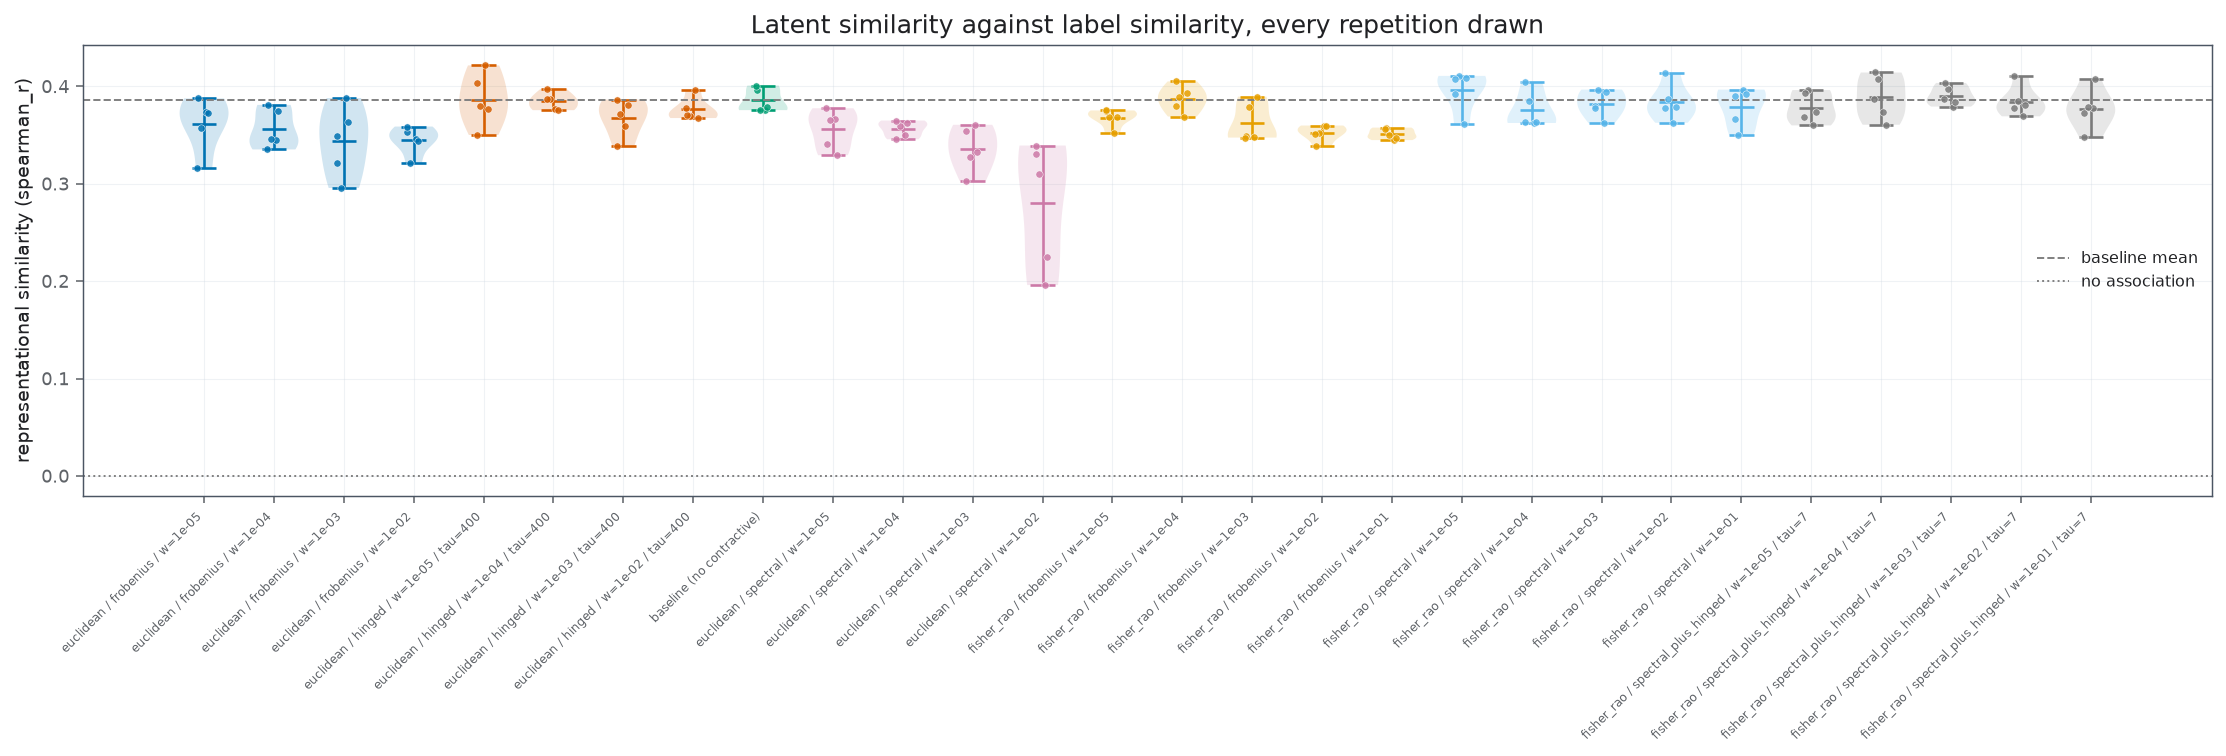

In [13]:
figure, ax = plt.subplots(figsize=(16.0, 5.5), dpi=theme.figure_dpi)
samples = {cell: group[rsa_column].to_numpy() for cell, group in rsa_frame.groupby("cell_label")}
for position, cell in enumerate(CELL_ORDER):
    values = samples.get(cell)
    if values is None or not len(values):
        continue
    plot_violin_with_points(
        values, position=position, ax=ax, width=0.7,
        color=CELL_COLOR[cell], point_size=14.0, jitter=0.10, theme=theme,
    )
if BASELINE_CELL in samples:
    ax.axhline(float(np.mean(samples[BASELINE_CELL])), color="grey", linestyle="--", linewidth=1, label="baseline mean")
ax.axhline(0.0, color="grey", linestyle=":", linewidth=1, label="no association")
ax.set_xticks(range(len(CELL_ORDER)))
ax.set_xticklabels(CELL_ORDER, rotation=45, ha="right", fontsize=6)
ax.set(ylabel=f"representational similarity ({rsa_column})", title="Latent similarity against label similarity, every repetition drawn")
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
ax.legend(fontsize=8, frameon=theme.legend_frame)
figure.tight_layout()

## Contrast against the baseline

### Methodology

#### Theoretical

As in `part_1`, repetitions of two cells are matched observations because they share their
split and dataloader seeds, so the comparison is paired and the interval is a two-sided 95%
Student-t interval on the paired differences. The contrast is reported for the statistics
that carry a direction of preference, and for realized sensitivity, which is the quantity
the penalty targets.

#### Implementation

`paired_contrast` pairs on repetition index. Applied to trace, effective rank, cross-seed
neighborhood overlap and the angular displacement at the largest perturbation. Neighborhood
overlap is defined per repetition pair rather than per repetition, so its ten values per
cell are compared unpaired against the baseline's ten and the interval is reported for
information rather than as a paired test.

#### Figure descriptions

The table lists, per cell and statistic, the mean paired difference against the baseline,
its confidence interval and whether that interval excludes zero. Sign conventions follow
the statistic: for trace and effective rank a positive difference means more variation or
more directions used; for angular displacement a negative difference means a less sensitive
encoder, which is the penalty's intended effect.

### Remarks

### Notes

In [14]:
def repetition_map(frame, cell, value_column, metric=None):
    selected = frame.query("cell_label == @cell")
    if metric is not None:
        selected = selected.query("metric == @metric")
    return {
        int(row.repetition): float(getattr(row, value_column))
        for row in selected.itertuples()
        if row.repetition is not None and np.isfinite(getattr(row, value_column))
    }


contrast_rows = []
for statistic, frame, value_column, metric in (
    ("trace", geometry_frame, "value", "trace"),
    ("effective_rank", geometry_frame, "value", "effective_rank"),
    ("participation_ratio", geometry_frame, "value", "participation_ratio"),
    ("cloud_asymmetry", geometry_frame, "value", "cloud_asymmetry"),
    ("angular_displacement", at_largest, "mean_angle_degrees", None),
    ("representational_similarity", rsa_frame, rsa_column, None),
):
    reference = repetition_map(frame, BASELINE_CELL, value_column, metric)
    for cell in CELL_ORDER:
        if cell == BASELINE_CELL:
            continue
        contrast = sweep.paired_contrast(repetition_map(frame, cell, value_column, metric), reference)
        contrast_rows.append({"statistic": statistic, "cell_label": cell, **contrast})
contrast_frame = pd.DataFrame(contrast_rows)
display(
    contrast_frame.pivot_table(index="cell_label", columns="statistic", values="mean_difference")
    .reindex([cell for cell in CELL_ORDER if cell != BASELINE_CELL]).round(4)
)

statistic,angular_displacement,cloud_asymmetry,effective_rank,participation_ratio,representational_similarity,trace
cell_label,,,,,,
euclidean / frobenius / w=1e-05,-1.8039,0.2311,-0.1121,-0.0536,-0.0242,-2.3113
euclidean / frobenius / w=1e-04,-2.3106,0.4004,-0.1233,-0.0510,-0.0292,-4.0043
euclidean / frobenius / w=1e-03,-2.5630,0.4719,-0.1213,0.0185,-0.0420,-4.7187
euclidean / frobenius / w=1e-02,-2.6599,0.4961,0.0019,0.2206,-0.0409,-4.9611
euclidean / hinged / w=1e-05 / tau=400,-0.6310,0.0583,-0.0083,0.0219,0.0008,-0.5826
euclidean / hinged / w=1e-04 / tau=400,-0.7051,0.0795,-0.0948,-0.0742,-0.0009,-0.7948
euclidean / hinged / w=1e-03 / tau=400,-0.8004,0.0986,-0.0525,-0.0439,-0.0180,-0.9864
euclidean / hinged / w=1e-02 / tau=400,-1.0170,0.1216,-0.0576,-0.0502,-0.0092,-1.2155
euclidean / spectral / w=1e-05,-1.0122,0.0036,0.0012,-0.0008,-0.0296,-0.0363


## Reproducible artifacts

### Methodology

#### Implementation

Long-form geometry, stability, sensitivity, structure and contrast records are persisted,
together with the realized evaluation-sample indices, so every figure can be regenerated
without re-encoding a model. Provenance records the campaigns, subsample fraction and
seeds, the geometry row cap, library versions, the commit and a hash of the analysis
module.

### Remarks

### Notes

In [15]:
frames = {
    "latent_geometry": geometry_frame,
    "representation_stability": stability_frame,
    "angular_sensitivity": sensitivity_frame,
    "angular_structure": structure_frame,
    "representational_similarity": rsa_frame,
    "baseline_contrasts": contrast_frame,
    "grid": grid_frame,
}
for name, frame in frames.items():
    frame.to_csv(ARTIFACT_DIR / f"{name}.csv", index=False)
pd.DataFrame({"dataset_index": test_split.indices}).to_csv(ARTIFACT_DIR / "sample_indices.csv", index=False)

metadata = {
    "campaigns": CAMPAIGNS,
    "pixel_fraction": PIXEL_FRACTION,
    "sample_seed": SAMPLE_SEED,
    "pair_count": PAIR_COUNT,
    "knn_neighbors": KNN_NEIGHBORS,
    "epsilons": list(EPSILONS),
    "test_sampled": test_split.sampled,
    "test_total": test_split.total,
    "models_evaluated": int(len(grid_frame)),
    "numpy": np.__version__,
    "torch": torch.__version__,
    "git_commit": subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip(),
    "analysis_sha256": hashlib.sha256(Path("src/msi_autoencoder_wrapper/analysis/autoencoder/experiments/sweep_evaluation.py").read_bytes()).hexdigest(),
}
(ARTIFACT_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2) + "\n")
logger.info("Wrote %s table(s) and provenance to %s", len(frames), ARTIFACT_DIR)
print(sorted(path.name for path in ARTIFACT_DIR.iterdir()))

2026-09-07 01:20:07,805 | INFO     | latent_geometry_sweep:30 | Wrote 7 table(s) and provenance to assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/part_2_latent_geometry_metric_weight_sweep_results


['angular_sensitivity.csv', 'angular_structure.csv', 'baseline_contrasts.csv', 'grid.csv', 'latent_geometry.csv', 'metadata.json', 'representation_stability.csv', 'representational_similarity.csv', 'sample_indices.csv']


## Results / Summary

### LLM

**The Fisher-Rao geometry solves the collapse the Euclidean geometry causes.** Latent
covariance trace at the baseline is 5.07. Under the Euclidean Frobenius penalty it falls to
2.75, 1.05, 0.34 and 0.099 across $\lambda = 10^{-5}$ to $10^{-2}$, retaining 2% of the
baseline's variation at the strongest weight. Under the Fisher-Rao spectral penalty it
holds at 5.18, 5.12, 5.12 and 5.01 over the same weights and only yields at $10^{-1}$
(3.10). The spectral-plus-hinge variant behaves the same. This is the campaign's central
result: the collapse was a property of the input metric, not of contractive regularization
as such.

**An internal consistency check passes.** With the population covariance convention,
$\operatorname{tr}\Sigma = D - \lVert\bar u\rVert^2$ must hold exactly. The baseline's
trace of 5.066 and cloud asymmetry of 0.493 satisfy it at $D=10$, and the identity holds
across the grid, so the measured contraction is not an artifact of the canonicalization.

**A pathology in the Euclidean spectral penalty, visible only in the sensitivity
measurement.** A contractive penalty should reduce the encoder's response to input
perturbation. Euclidean Frobenius does so monotonically, to the point of over-contraction
(0.94 down to 0.08 degrees against the baseline's 2.74). Euclidean spectral instead
*increases* it sharply at moderate weight: 18.5 degrees at $\lambda=10^{-3}$ and 22.7 at
$10^{-2}$, roughly eight times the baseline. The Fisher-Rao arm shows the same signature
only at $\lambda=10^{-1}$ (10.4 degrees).

**Interpretation, stated as inference rather than measurement.** Every case of exploding
angular sensitivity coincides with a collapsed trace, at or below roughly 3. Canonicalizing
a cloud whose variation has nearly vanished divides by a near-zero scale, so a small input
perturbation produces a large movement in the normalized direction. The penalty shrinks the
raw code while the canonicalization restores its scale, amplifying noise. This explains the
sign reversal but is not itself tested here; a direct test would compare the raw and
canonicalized responses on the same perturbations.

**Cross-seed reproducibility follows the same split.** Neighborhood overlap between
repetitions is 0.685 at the baseline and holds at 0.68 to 0.69 across the Fisher-Rao arm,
while Euclidean spectral falls to 0.434 at $\lambda=10^{-3}$ and 0.223 at $10^{-2}$: at that
setting two seeds agree on under a quarter of each pixel's neighbors. Centered kernel
alignment is far less discriminating (0.91 to 0.98 everywhere), which is expected since it
compares global similarity structure rather than local neighborhoods, and is a reason not
to rely on it alone.

**No penalty makes the representation more reproducible than the baseline.** The best
Fisher-Rao cells match the baseline's neighborhood overlap rather than exceeding it, so the
regularizer's value here is that it does no damage, not that it stabilizes the solution.

**Caveats.** Training penalizes the Jacobian of $u$ while the angular statistics describe
the normalized direction $q$; these are different maps and a threshold or weight calibrated
on one does not transfer to the other. The perturbation used for the sensitivity curve is
isotropic in the ambient input space, deliberately not each arm's own geometry, since using
the trained geometry would make the comparison circular.

### Person